# Customer RFM Analysis

## Introduction

Customer segmentation is an important customer analytics technique that enables businesses to better understand customer purchasing behaviour and allocate marketing resources more effectively. One of the most widely adopted approaches is **Recency, Frequency and Monetary (RFM) Analysis**, which segments customers according to their purchasing history.

RFM analysis evaluates customers using three behavioural dimensions:

- **Recency (R):** How recently a customer made their latest purchase.
- **Frequency (F):** How often a customer makes purchases.
- **Monetary (M):** How much money a customer has spent.

Customers who purchase recently, purchase frequently and spend more are generally considered more valuable to the business.

This analysis is performed using the cleaned **Transactions** dataset because it contains the complete purchase history for each customer, including transaction dates, transaction status and sales values. These variables are essential for calculating Recency, Frequency and Monetary metrics.

The objectives of this analysis are to:

- Calculate Recency, Frequency and Monetary values for every customer.
- Assign RFM scores based on customer purchasing behaviour.
- Segment customers into meaningful business groups.
- Provide actionable business insights and recommendations to support customer relationship management and marketing strategies.

## Data Preparation

Before calculating the RFM metrics, the transaction dataset is prepared to ensure that only valid customer purchase records are included in the analysis.

Since RFM analysis measures actual customer purchasing behaviour, only **approved transactions** are retained. Cancelled transactions are excluded because they do not generate realised revenue and therefore should not contribute to customer value.

The key variables required for the analysis are:

- **customer_id** – identifies each unique customer.
- **transaction_date** – used to calculate Recency.
- **transaction_id** – used to calculate Frequency.
- **list_price** – used to calculate Monetary value.

The following section imports the cleaned transaction dataset and verifies that the required variables are available before calculating the RFM metrics.

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

In [ ]:
# Load the cleaned Transactions dataset

transactions = pd.read_excel("Transactions_Cleaned.xlsx")

transactions.head()

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date
0,1293,67,1931,2017-01-01,1,Approved,Norco Bicycles,Road,medium,medium,544.05,376.84,2005-10-22
1,3525,50,3490,2017-01-01,1,Approved,Giant Bicycles,Standard,medium,medium,642.70,211.37,2002-03-22
2,12544,36,3062,2017-01-01,0,Approved,Solex,Standard,low,medium,945.04,507.58,1995-12-19
3,12485,85,2805,2017-01-01,1,Approved,WeareA2B,Standard,medium,medium,1228.07,400.91,2000-05-22
4,3518,58,523,2017-01-01,1,Approved,OHM Cycles,Standard,medium,medium,912.52,141.40,2015-05-21


In [ ]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19803 entries, 0 to 19802
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   transaction_id           19803 non-null  int64         
 1   product_id               19803 non-null  int64         
 2   customer_id              19803 non-null  int64         
 3   transaction_date         19803 non-null  datetime64[ns]
 4   online_order             19803 non-null  int64         
 5   order_status             19803 non-null  object        
 6   brand                    19803 non-null  object        
 7   product_line             19803 non-null  object        
 8   product_class            19803 non-null  object        
 9   product_size             19803 non-null  object        
 10  list_price               19803 non-null  float64       
 11  standard_cost            19803 non-null  float64       
 12  product_first_sold_date  19803 n

In [ ]:
required_columns = [
    "customer_id",
    "transaction_id",
    "transaction_date",
    "order_status",
    "list_price"
]

transactions[required_columns].head()

,customer_id,transaction_id,transaction_date,order_status,list_price
0,1931,1293,2017-01-01,Approved,544.05
1,3490,3525,2017-01-01,Approved,642.70
2,3062,12544,2017-01-01,Approved,945.04
3,2805,12485,2017-01-01,Approved,1228.07
4,523,3518,2017-01-01,Approved,912.52


## Data Validation for RFM Analysis

Before calculating the RFM metrics, several validation checks are performed to ensure the transaction data is suitable for customer segmentation.

The validation focuses on:

- Transaction status to determine whether cancelled transactions should be included.
- The transaction date range to establish the observation period.
- The number of unique customers represented in the dataset.
- Duplicate transaction identifiers to verify transaction integrity.

These checks provide confidence that the dataset is appropriate for calculating Recency, Frequency and Monetary metrics.

In [ ]:
# Transaction status distribution

transactions["order_status"].value_counts()

,count
order_status,
Approved,19625
Cancelled,178


In [ ]:
# Transaction period

print("Earliest transaction:", transactions["transaction_date"].min())
print("Latest transaction:", transactions["transaction_date"].max())

Earliest transaction: 2017-01-01 00:00:00
Latest transaction: 2017-12-30 00:00:00


In [ ]:
# Number of unique customers

transactions["customer_id"].nunique()

3494

In [ ]:
# Check duplicate transaction IDs

transactions["transaction_id"].duplicated().sum()

np.int64(0)

### Validation Results

The transaction dataset contains **19,803** transaction records from **3,494** unique customers over the period from **1 January 2017** to **30 December 2017**, representing one year of customer purchasing activity.

Transaction status validation identified **19,625 approved transactions (99.10%)** and **178 cancelled transactions (0.90%)**. Since cancelled transactions do not represent completed purchases or realised revenue, they will be excluded from the RFM analysis. This ensures that Recency, Frequency and Monetary metrics reflect actual customer purchasing behaviour.

No duplicate transaction identifiers were detected, confirming that each transaction is uniquely recorded. In addition, the required variables for RFM analysis are complete and have appropriate data types, indicating that the dataset is suitable for customer segmentation.

## Prepare Transaction Data

Following the validation process, only approved transactions are retained for the RFM analysis. This ensures that the calculated customer metrics are based solely on completed purchases that generated revenue.

The prepared dataset will be used to calculate Recency, Frequency and Monetary values for each customer.

In [ ]:
# Keep only approved transactions

transactions_rfm = transactions[
    transactions["order_status"] == "Approved"
].copy()

print(f"Number of transactions: {len(transactions_rfm):,}")
print(f"Number of customers: {transactions_rfm['customer_id'].nunique():,}")

Number of transactions: 19,625
Number of customers: 3,493


## Calculate Recency

Recency measures how recently each customer made their most recent purchase relative to a reference (snapshot) date.

The snapshot date is defined as **one day after the latest transaction date** in the dataset. This approach is widely used in customer analytics because it ensures that the most recent customer purchase has a Recency value of one day while maintaining a consistent observation period for all customers.

A lower Recency value indicates a more recently active customer, whereas a higher Recency value indicates that a customer has not made a purchase for a longer period.

In [ ]:
# Define the snapshot date

snapshot_date = transactions_rfm["transaction_date"].max() + pd.Timedelta(days=1)

print("Snapshot Date:", snapshot_date.date())

Snapshot Date: 2017-12-31


In [ ]:
# Calculate Recency

recency = (
    transactions_rfm
    .groupby("customer_id")
    .agg(
        Last_Purchase=("transaction_date", "max")
    )
)

recency["Recency"] = (
    snapshot_date - recency["Last_Purchase"]
).dt.days

recency.head()

,Last_Purchase,Recency
customer_id,,
1,2017-12-23,8
2,2017-08-24,129
3,2017-09-19,103
4,2017-06-18,196
5,2017-12-14,17


In [ ]:
recency["Recency"].describe()

,Recency
count,3493.000000
mean,62.805039
std,58.568975
min,1.000000
25%,18.000000
50%,45.000000
75%,88.000000
max,354.000000


### Observation

The Recency metric was successfully calculated for **3,493 customers** using **31 December 2017** as the snapshot date.

The Recency values range from **1 day** to **354 days**, with an average of approximately **63 days** and a median of **45 days**. This indicates that half of the customers made their most recent purchase within 45 days of the snapshot date.

The first quartile (18 days) suggests that 25% of customers purchased within the last 18 days, while the third quartile (88 days) indicates that 75% of customers made a purchase within the previous 88 days. Customers with lower Recency values are considered more recently active and are generally more likely to make future purchases than customers with higher Recency values.

## Calculate Frequency

Frequency measures how often a customer makes purchases during the observation period.

In this analysis, Frequency is defined as the **number of approved transactions** completed by each customer. Each approved transaction represents a successful purchase and contributes equally to the customer's purchasing activity.

Customers with higher Frequency values purchase more often and are generally considered more engaged than customers who purchase less frequently.

In [ ]:
# Calculate Frequency

frequency = (
    transactions_rfm
    .groupby("customer_id")
    .agg(
        Frequency=("transaction_id", "count")
    )
)

frequency.head()

,Frequency
customer_id,
1,11
2,3
3,8
4,2
5,6


In [ ]:
frequency["Frequency"].describe()

,Frequency
count,3493.000000
mean,5.618380
std,2.296612
min,1.000000
25%,4.000000
50%,5.000000
75%,7.000000
max,14.000000


### Observation

The Frequency metric was successfully calculated for **3,493 customers** based on the number of approved transactions completed during the observation period.

Customers completed between **1 and 14 purchases**, with an average Frequency of approximately **5.62 transactions** and a median of **5 transactions**. The first quartile (4 transactions) indicates that 25% of customers made four or fewer purchases, while the third quartile (7 transactions) indicates that 75% of customers completed seven or fewer purchases during the year.

Overall, the Frequency distribution suggests that most customers purchased multiple times throughout the observation period, indicating a generally active customer base. Customers with higher Frequency values demonstrate stronger purchasing engagement and are likely to represent more loyal customers than those with fewer transactions.

## Calculate Monetary

Monetary measures the total amount of money a customer has spent during the observation period.

In this analysis, Monetary is calculated as the **sum of the list prices** of all approved transactions for each customer. The list price is used as the sales value generated by each completed purchase, providing a measure of each customer's total revenue contribution.

Customers with higher Monetary values have generated greater revenue and are generally considered more valuable to the business.

In [ ]:
# Calculate Monetary

monetary = (
    transactions_rfm
    .groupby("customer_id")
    .agg(
        Monetary=("list_price", "sum")
    )
)

monetary.head()

,Monetary
customer_id,
1,9084.45
2,4149.07
3,9888.23
4,1047.72
5,5903.20


In [ ]:
monetary["Monetary"].describe()

,Monetary
count,3493.000000
mean,6223.731832
std,2929.135199
min,60.340000
25%,4117.570000
50%,5947.980000
75%,8078.030000
max,19071.320000


### Observation

The Monetary metric was successfully calculated for **3,493 customers** based on the total value of approved purchases during the observation period.

Customer spending ranges from **AUD 60.34** to **AUD 19,071.32**, with an average Monetary value of approximately **AUD 6,223.73** and a median of **AUD 5,947.98**.

The first quartile is **AUD 4,117.57**, meaning that 25% of customers spent no more than this amount. The third quartile is **AUD 8,078.03**, meaning that 75% of customers spent no more than this amount during the observation period.

The wide range of Monetary values indicates considerable variation in customer spending behaviour. Customers with higher Monetary values contributed substantially more revenue and may represent some of the business's most valuable customers.

## Create the RFM Table

The Recency, Frequency and Monetary metrics are combined into a single customer-level dataset. Each row represents one unique customer and summarises their purchasing behaviour during the observation period.

This integrated RFM table provides the foundation for assigning RFM scores, segmenting customers and identifying groups with different levels of customer value.

In [ ]:
# Combine Recency, Frequency and Monetary metrics

rfm = (
    recency[["Recency"]]
    .join(frequency[["Frequency"]])
    .join(monetary[["Monetary"]])
)

rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
1,8,11,9084.45
2,129,3,4149.07
3,103,8,9888.23
4,196,2,1047.72
5,17,6,5903.20


In [ ]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3493 entries, 1 to 5034
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    3493 non-null   int64  
 1   Frequency  3493 non-null   int64  
 2   Monetary   3493 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 109.2 KB


In [ ]:
rfm.describe().round(2)

,Recency,Frequency,Monetary
count,3493.00,3493.00,3493.00
mean,62.81,5.62,6223.73
std,58.57,2.30,2929.14
min,1.00,1.00,60.34
25%,18.00,4.00,4117.57
50%,45.00,5.00,5947.98
75%,88.00,7.00,8078.03
max,354.00,14.00,19071.32


### Observation

The individual Recency, Frequency and Monetary metrics were successfully integrated into a single RFM table containing **3,493 unique customers**. Each customer is represented by one record summarising their purchasing behaviour during the observation period.

The RFM table contains three variables:

- **Recency** – days since the customer's most recent approved purchase.
- **Frequency** – total number of approved transactions.
- **Monetary** – total spending based on the sum of approved transaction values.

The integrated dataset contains no missing values and provides a complete customer-level view for the subsequent RFM scoring and customer segmentation process.

## Examine the Distribution of RFM Metrics

Before assigning RFM scores, the distributions of the Recency, Frequency and Monetary metrics are examined.

Understanding the distribution of each variable helps determine whether quartile-based scoring is an appropriate method for customer segmentation. Quartile scoring divides customers into four approximately equal-sized groups, providing an objective and data-driven approach when predefined business thresholds are unavailable.

In [ ]:
# Summary statistics of RFM metrics

rfm.describe().round(2)

,Recency,Frequency,Monetary
count,3493.00,3493.00,3493.00
mean,62.81,5.62,6223.73
std,58.57,2.30,2929.14
min,1.00,1.00,60.34
25%,18.00,4.00,4117.57
50%,45.00,5.00,5947.98
75%,88.00,7.00,8078.03
max,354.00,14.00,19071.32


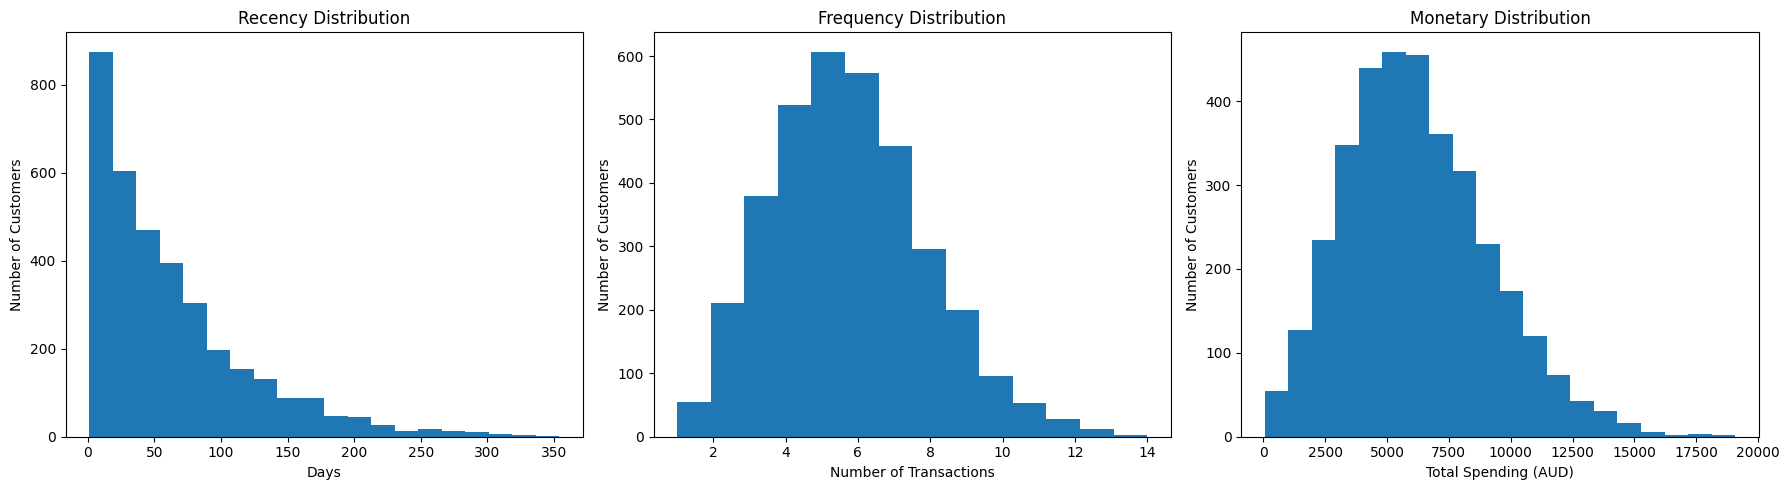

In [ ]:
# Visualise the distribution of RFM metrics

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(rfm["Recency"], bins=20)
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Number of Customers")

axes[1].hist(rfm["Frequency"], bins=14)
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of Transactions")
axes[1].set_ylabel("Number of Customers")

axes[2].hist(rfm["Monetary"], bins=20)
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Total Spending (AUD)")
axes[2].set_ylabel("Number of Customers")

plt.tight_layout()

plt.show()

### Observation

The distributions of the Recency, Frequency and Monetary metrics were examined prior to assigning RFM scores.

The Recency distribution is positively skewed, indicating that many customers made purchases relatively recently, while fewer customers have been inactive for extended periods. Both Frequency and Monetary exhibit moderately right-skewed distributions, with most customers making between four and seven purchases and generating moderate levels of total spending during the observation period.

Given these distributions and the absence of predefined business thresholds, a quartile-based scoring approach is considered appropriate. Quartile scoring provides an objective, data-driven and reproducible method for assigning customer scores while creating approximately equal-sized customer groups for subsequent segmentation.

## RFM Scoring Methodology

Each customer is assigned a score from **1 to 4** for Recency, Frequency and Monetary value using quartile-based scoring.

Quartiles divide customers into four groups based on the distribution of each RFM metric. This approach is used because predefined business thresholds are unavailable and quartile scoring provides an objective, reproducible and data-driven method.

The scores are assigned as follows:

- **Recency:** Lower values receive higher scores because a more recent purchase indicates stronger current engagement.
  - Score 4 = most recent customers
  - Score 1 = least recent customers

- **Frequency:** Higher values receive higher scores because frequent purchases indicate stronger engagement and loyalty.
  - Score 4 = most frequent customers
  - Score 1 = least frequent customers

- **Monetary:** Higher values receive higher scores because greater spending indicates a higher revenue contribution.
  - Score 4 = highest-spending customers
  - Score 1 = lowest-spending customers

The three component scores will later be combined into a three-digit RFM code. For example, a customer with Recency = 4, Frequency = 3 and Monetary = 4 will receive an RFM code of **434**.

## RFM Scoring Methodology

To enable customer segmentation, each customer is assigned a **Recency (R)**, **Frequency (F)** and **Monetary (M)** score using a **quartile-based scoring approach**.

Quartile scoring divides customers into four groups according to the distribution of each RFM metric. This method is adopted because predefined business thresholds are unavailable for the dataset, making quartile-based scoring an objective, data-driven and reproducible approach. In addition, quartiles produce approximately equal-sized customer groups, facilitating meaningful comparisons and subsequent customer segmentation.

The scoring rules are defined as follows:

- **Recency (R):** Customers with more recent purchases receive higher scores because recent purchasing activity generally indicates stronger customer engagement.
  - Score **4** = Most recent customers
  - Score **1** = Least recent customers

- **Frequency (F):** Customers who complete more approved transactions receive higher scores because frequent purchasing reflects stronger customer loyalty and engagement.
  - Score **4** = Most frequent customers
  - Score **1** = Least frequent customers

- **Monetary (M):** Customers with higher total spending receive higher scores because they contribute greater revenue to the business.
  - Score **4** = Highest spending customers
  - Score **1** = Lowest spending customers

After assigning the individual R, F and M scores, they are combined into a three-digit **RFM Code**, which uniquely represents each customer's purchasing behaviour.

The RFM Code is calculated as:

**RFM Code = (R Score × 100) + (F Score × 10) + M Score**

The multiplication by **100** and **10** is used solely to position each score within the final three-digit code:

- The **hundreds digit** represents the **Recency Score**.
- The **tens digit** represents the **Frequency Score**.
- The **ones digit** represents the **Monetary Score**.

These positional multipliers do **not** imply that Recency is weighted more heavily than Frequency or Monetary. Their only purpose is to preserve the three individual scores within a single interpretable code.

For example, if a customer has:

- Recency Score = **4**
- Frequency Score = **3**
- Monetary Score = **4**

then:

**RFM Code = (4 × 100) + (3 × 10) + 4 = 434**

This code should be interpreted digit by digit:

- **4** → High Recency (recent purchaser)
- **3** → Moderate-to-high Frequency
- **4** → High Monetary value

Rather than interpreting the RFM Code as a numerical magnitude, it should be viewed as a compact representation of the customer's purchasing behaviour across the three RFM dimensions. Customers with similar RFM Codes exhibit similar purchasing patterns and can therefore be grouped into meaningful customer segments for subsequent business analysis and marketing strategies.



## Assign RFM Scores

Following the defined scoring methodology, quartile-based scoring is applied to the Recency, Frequency and Monetary metrics.

Each customer receives a score ranging from **1** to **4** for each RFM dimension.

Since lower Recency values indicate more recent purchasing behaviour, the Recency scores are assigned in reverse order, with the most recent customers receiving the highest score. In contrast, customers with higher Frequency and Monetary values receive higher scores because they demonstrate stronger purchasing engagement and greater revenue contribution.

The resulting R, F and M scores will be combined to create each customer's RFM Code.

In [ ]:
# Assign Recency scores (4 = most recent, 1 = least recent)

rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=4,
    labels=[4, 3, 2, 1]
).astype(int)

rfm[["Recency", "R_Score"]].head()

,Recency,R_Score
customer_id,,
1,8,4
2,129,1
3,103,1
4,196,1
5,17,4


In [ ]:
rfm["R_Score"].value_counts().sort_index()

,count
R_Score,
1,859
2,879
3,880
4,875


### Observation

The Recency scores were successfully assigned using quartile-based scoring. Customers with the most recent purchases received higher scores, while customers with less recent purchases received lower scores.

The resulting score distribution is well balanced, with each score representing approximately one-quarter of the customer population:

| Recency Score | Number of Customers |
|--------------:|--------------------:|
| 1 | 859 |
| 2 | 879 |
| 3 | 880 |
| 4 | 875 |

The small differences in group sizes are expected because multiple customers share identical Recency values at the quartile boundaries. Overall, the distribution confirms that quartile-based scoring provides a balanced and objective representation of customer recency.

## Assign Frequency Scores

Following the same quartile-based scoring methodology, Frequency scores are assigned to each customer.

Unlike Recency, higher Frequency values indicate stronger purchasing engagement. Therefore, customers who completed more approved transactions receive higher Frequency scores, while customers with fewer approved transactions receive lower scores.

The resulting Frequency scores will be validated to ensure that the quartile-based scoring produces a balanced distribution suitable for customer segmentation.

In [ ]:
# Assign Frequency scores (4 = most frequent, 1 = least frequent)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"],
    q=4,
    labels=[1, 2, 3, 4],
    duplicates="drop"
).astype(int)

rfm[["Frequency", "F_Score"]].head()

,Frequency,F_Score
customer_id,,
1,11,4
2,3,1
3,8,4
4,2,1
5,6,3


In [ ]:
rfm["F_Score"].value_counts().sort_index()

,count
F_Score,
1,1167
2,607
3,1032
4,687


In [ ]:
rfm.groupby("F_Score")["Frequency"].describe()

,count,mean,std,min,25%,50%,75%,max
F_Score,,,,,,,,
1,1167.0,3.173950,0.887152,1.0,3.0,3.0,4.0,4.0
2,607.0,5.000000,0.000000,5.0,5.0,5.0,5.0,5.0
3,1032.0,6.443798,0.497072,6.0,6.0,6.0,7.0,7.0
4,687.0,9.077147,1.277132,8.0,8.0,9.0,10.0,14.0


In [ ]:
pd.crosstab(
    rfm["Frequency"],
    rfm["F_Score"]
)

F_Score,1,2,3,4
Frequency,,,,
1,55,0,0,0
2,210,0,0,0
3,379,0,0,0
4,523,0,0,0
5,0,607,0,0
6,0,0,574,0
7,0,0,458,0
8,0,0,0,296
9,0,0,0,199


### Observation

The Frequency scores were successfully assigned using quartile-based scoring.

Unlike Recency and Monetary, Frequency is a discrete variable with only **14 unique purchase frequencies**. Consequently, many customers share identical Frequency values. To ensure customers with identical purchasing behaviour receive the same score, identical Frequency values were intentionally assigned to the same quartile group. As a result, the four score groups are not perfectly equal in size.

The resulting Frequency score ranges are summarised below:

| Frequency Score | Frequency Range | Number of Customers |
|---------------:|----------------:|--------------------:|
| 1 | 1–4 | 1,167 |
| 2 | 5 | 607 |
| 3 | 6–7 | 1,032 |
| 4 | 8–14 | 687 |

Although the customer counts differ across the four groups, this outcome is expected and methodologically appropriate. Preserving identical scores for customers with the same purchase frequency is more important than forcing perfectly equal-sized groups, ensuring consistency and fairness in the customer segmentation process.

## Assign Monetary Scores

Following the same quartile-based scoring methodology, Monetary scores are assigned to each customer.

Customers with higher total spending contribute greater revenue to the business and therefore receive higher Monetary scores. Since Monetary is a continuous variable with a wide range of spending values, quartile-based scoring is expected to produce approximately equal-sized customer groups.

The assigned Monetary scores will be validated before constructing the final RFM Code.

In [ ]:
# Assign Monetary scores (4 = highest spending, 1 = lowest spending)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    q=4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm[["Monetary", "M_Score"]].head()

,Monetary,M_Score
customer_id,,
1,9084.45,4
2,4149.07,2
3,9888.23,4
4,1047.72,1
5,5903.20,2


In [ ]:
rfm["M_Score"].value_counts().sort_index()

,count
M_Score,
1,874
2,873
3,873
4,873


### Observation

The Monetary scores were successfully assigned using quartile-based scoring.

Customers with higher total spending received higher Monetary scores, while customers with lower total spending received lower scores. Since Monetary is a continuous variable with a wide range of spending values, quartile-based scoring produced an almost perfectly balanced distribution across the four customer groups.

The resulting Monetary score distribution is summarised below:

| Monetary Score | Number of Customers |
|---------------:|--------------------:|
| 1 | 874 |
| 2 | 873 |
| 3 | 873 |
| 4 | 873 |

The nearly identical group sizes confirm that quartile-based scoring is well suited for the Monetary metric and provides an objective and consistent representation of customer spending behaviour.

## Construct the RFM Code

After assigning the individual Recency, Frequency and Monetary scores, the three scores are combined to create each customer's **RFM Code**.

The RFM Code provides a compact representation of customer purchasing behaviour by preserving the individual scores for each RFM dimension within a single three-digit code.

In addition to the RFM Code, a **Total RFM Score** is calculated by summing the three component scores. While the RFM Code is used as the primary basis for customer segmentation, the Total RFM Score provides a simple summary measure of overall customer value and can be useful for descriptive analysis.

In [ ]:
# Create the three-digit RFM Code

rfm["RFM_Code"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

In [ ]:
# Calculate the Total RFM Score

rfm["Total_RFM_Score"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)

In [ ]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Code,Total_RFM_Score
customer_id,,,,,,,,
1,8,11,9084.45,4,4,4,444,12
2,129,3,4149.07,1,1,2,112,4
3,103,8,9888.23,1,4,4,144,9
4,196,2,1047.72,1,1,1,111,3
5,17,6,5903.20,4,3,2,432,9


### Observation

The final RFM table was successfully constructed by combining the original RFM metrics with their corresponding quartile-based scores.

Each customer is represented by a single record containing:

- Recency, Frequency and Monetary metrics.
- Quartile-based R, F and M scores.
- A three-digit RFM Code representing the customer's purchasing behaviour.
- A Total RFM Score summarising the three individual scores.

The completed RFM table provides a comprehensive customer-level dataset that is ready for customer segmentation and subsequent business analysis.

In [ ]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3493 entries, 1 to 5034
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Recency          3493 non-null   int64  
 1   Frequency        3493 non-null   int64  
 2   Monetary         3493 non-null   float64
 3   R_Score          3493 non-null   int64  
 4   F_Score          3493 non-null   int64  
 5   M_Score          3493 non-null   int64  
 6   RFM_Code         3493 non-null   object 
 7   Total_RFM_Score  3493 non-null   int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 245.6+ KB


## Explore the Distribution of RFM Codes

Before grouping customers into broader business segments, the distribution of RFM Codes is examined.

Each RFM Code represents a unique combination of customer recency, purchase frequency and spending behaviour. Exploring the frequency of these codes provides an overview of the customer population and identifies the most common purchasing patterns.

Understanding the distribution of RFM Codes helps ensure that subsequent customer segments are both meaningful and representative of the observed customer behaviours.

In [ ]:
# Number of unique RFM Codes

rfm["RFM_Code"].nunique()

56

In [ ]:
# Distribution of RFM Codes

rfm["RFM_Code"].value_counts()

,count
RFM_Code,
111,337
444,203
344,190
211,179
433,141
...,...
424,4
342,3
142,2


In [ ]:
# Top 15 most common RFM Codes

rfm["RFM_Code"].value_counts().head(15)

,count
RFM_Code,
111,337
444,203
344,190
211,179
433,141
233,138
244,130
333,129
311,127


## Analyse the Distribution of RFM Codes

The RFM Code distribution was examined to understand the diversity of customer purchasing behaviours before assigning broader customer segments.

A total of **56 unique RFM Codes** were observed from the **64 possible score combinations** (4 × 4 × 4). This indicates considerable variation in customer purchasing behaviour across the three RFM dimensions.

The most common RFM Codes include **111**, **444**, **344**, **211**, and **433**, suggesting that the customer base contains both highly engaged customers and customers with relatively low purchasing activity.

As several RFM Codes contain only a small number of customers, assigning a unique business strategy to every individual code would not be practical. Instead, similar RFM Codes will be grouped into broader customer segments based on shared purchasing characteristics. This approach improves interpretability while maintaining meaningful behavioural distinctions between customer groups.

## Customer Segmentation

After constructing the RFM table, customers are grouped into broader business segments based on their purchasing behaviour.

While the RFM Code provides a detailed representation of each customer's Recency, Frequency and Monetary characteristics, managing 56 unique RFM Codes individually would be impractical from a business perspective.

Therefore, customers are grouped into broader behavioural segments that share similar purchasing patterns. These segments enable organisations to better understand their customer base, develop targeted marketing strategies, improve customer retention and allocate resources more effectively.

The segmentation framework used in this analysis is based on the combined interpretation of Recency, Frequency and Monetary scores and follows commonly adopted customer relationship management (CRM) practices.

## Define Customer Segmentation Rules

To transform the RFM scores into actionable business insights, customers are classified into broader behavioural segments based on their Recency, Frequency and Monetary characteristics.

Rather than treating each of the 56 observed RFM Codes as an independent customer segment, similar purchasing behaviours are grouped into a smaller number of business-oriented segments commonly used in Customer Relationship Management (CRM).

This approach improves interpretability while enabling organisations to develop targeted marketing strategies, customer retention initiatives and loyalty programmes for customers with similar purchasing behaviours.

In [ ]:
def segment_customer(row):

    R = row["R_Score"]
    F = row["F_Score"]
    M = row["M_Score"]

    # Champions
    if R >= 3 and F >= 3 and M >= 3:
        return "Champions"

    # Loyal Customers
    elif R >= 3 and F >= 3:
        return "Loyal Customers"

    # Potential Loyalists
    elif R >= 3 and F == 2:
        return "Potential Loyalists"

    # New Customers
    elif R == 4 and F == 1:
        return "New Customers"

    # Promising
    elif R == 3 and F == 1:
        return "Promising"

    # Can't Lose Them
    elif R == 1 and F >= 3 and M >= 3:
        return "Can't Lose Them"

    # At Risk
    elif R <= 2 and F >= 3:
        return "At Risk"

    # Need Attention
    elif R == 2 and F == 2:
        return "Need Attention"

    # Lost Customers
    else:
        return "Lost Customers"

In [ ]:
rfm["Customer_Segment"] = rfm.apply(segment_customer, axis=1)

In [ ]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Code,Total_RFM_Score,Customer_Segment
customer_id,,,,,,,,,
1,8,11,9084.45,4,4,4,444,12,Champions
2,129,3,4149.07,1,1,2,112,4,Lost Customers
3,103,8,9888.23,1,4,4,144,9,Can't Lose Them
4,196,2,1047.72,1,1,1,111,3,Lost Customers
5,17,6,5903.20,4,3,2,432,9,Loyal Customers


### Validate Customer Segment Profiles

After assigning customers to behavioural segments, the segmentation results are validated by comparing the average Recency, Frequency and Monetary characteristics of each segment.

This validation step is important because segment labels should accurately reflect the purchasing behaviour represented by the underlying RFM scores. For example, Champions should demonstrate strong recent activity, frequent purchasing and high spending, while Lost Customers should generally show low engagement across these dimensions.

The segment profiles will be reviewed before proceeding to broader interpretation or business recommendations.

In [ ]:
segment_profile = (
    rfm.groupby("Customer_Segment")
       .agg(
           Customers=("Customer_Segment", "size"),
           Average_Recency=("Recency", "mean"),
           Average_Frequency=("Frequency", "mean"),
           Average_Monetary=("Monetary", "mean"),
           Average_RFM_Score=("Total_RFM_Score", "mean")
       )
       .round({
           "Average_Recency": 2,
           "Average_Frequency": 2,
           "Average_Monetary": 2,
           "Average_RFM_Score": 2
       })
       .sort_values("Average_RFM_Score", ascending=False)
)

segment_profile

,Customers,Average_Recency,Average_Frequency,Average_Monetary,Average_RFM_Score
Customer_Segment,,,,,
Champions,897,20.12,7.93,9145.12,10.65
Loyal Customers,149,20.16,6.42,5016.53,8.46
At Risk,494,69.47,7.22,7838.29,8.44
Can't Lose Them,179,124.45,6.97,8256.90,7.74
Potential Loyalists,292,20.84,5.00,5443.92,7.67
New Customers,207,10.17,3.47,3945.78,6.53
Need Attention,153,65.12,5.00,5291.78,6.16
Promising,210,31.74,3.32,3696.00,5.44
Lost Customers,912,128.19,3.40,3779.12,4.02


## Analyse Customer Segment Distribution

After validating the customer segmentation framework, the distribution of customers across each segment is examined.

Understanding the size of each customer segment provides valuable insight into the composition of the customer base and helps organisations prioritise customer relationship management (CRM) strategies.

For example, a large proportion of Champions indicates a strong base of highly engaged customers, while a high proportion of Lost or At Risk customers may highlight opportunities for customer retention and reactivation initiatives.

In [ ]:
segment_distribution = (
    rfm["Customer_Segment"]
    .value_counts()
    .rename_axis("Customer Segment")
    .reset_index(name="Customers")
)

segment_distribution["Percentage"] = (
    segment_distribution["Customers"]
    / segment_distribution["Customers"].sum()
    * 100
).round(2)

segment_distribution

,Customer Segment,Customers,Percentage
0,Lost Customers,912,26.11
1,Champions,897,25.68
2,At Risk,494,14.14
3,Potential Loyalists,292,8.36
4,Promising,210,6.01
5,New Customers,207,5.93
6,Can't Lose Them,179,5.12
7,Need Attention,153,4.38
8,Loyal Customers,149,4.27


### Observation

The customer segmentation results indicate that the customer base is distributed across nine behavioural segments, reflecting different levels of customer engagement and purchasing value.

The largest segment is **Lost Customers**, representing **26.11%** of all customers. This suggests that a considerable proportion of customers have low recent engagement and may require reactivation strategies or may no longer be active.

The second largest segment is **Champions** (**25.68%**), indicating that the business has a substantial group of highly valuable customers who purchase frequently, spend more and remain actively engaged. Retaining these customers should remain a strategic priority.

The **At Risk** segment accounts for **14.14%** of customers, highlighting an important opportunity for customer retention before these customers become inactive.

The remaining customer segments represent between **4% and 8%** of the customer base and provide opportunities for targeted marketing initiatives, customer development and loyalty programmes based on their purchasing behaviours.

## Revenue Contribution by Customer Segment

While the number of customers within each segment provides an overview of the customer base, it does not necessarily reflect the economic value of each segment.

To better understand the financial contribution of each customer segment, the total revenue generated by customers within each segment is calculated. In addition, the percentage contribution to overall revenue is examined to identify which customer groups create the greatest business value.

This analysis enables organisations to prioritise customer retention and marketing strategies by focusing on the segments that contribute most significantly to total revenue.

In [ ]:
segment_revenue = (
    rfm.groupby("Customer_Segment")
       .agg(
           Customers=("Customer_Segment", "size"),
           Total_Revenue=("Monetary", "sum")
       )
       .reset_index()
)

segment_revenue["Revenue_Percentage"] = (
    segment_revenue["Total_Revenue"]
    / segment_revenue["Total_Revenue"].sum()
    * 100
).round(2)

segment_revenue = segment_revenue.sort_values(
    "Total_Revenue",
    ascending=False
)

segment_revenue

,Customer_Segment,Customers,Total_Revenue,Revenue_Percentage
2,Champions,897,8203173.55,37.73
0,At Risk,494,3872114.14,17.81
3,Lost Customers,912,3446555.13,15.85
7,Potential Loyalists,292,1589623.98,7.31
1,Can't Lose Them,179,1477984.93,6.80
6,New Customers,207,816776.82,3.76
5,Need Attention,153,809642.80,3.72
8,Promising,210,776160.78,3.57
4,Loyal Customers,149,747463.16,3.44


In [ ]:
segment_revenue["Total_Revenue"] = (
    segment_revenue["Total_Revenue"]
    .round(2)
)

segment_revenue

,Customer_Segment,Customers,Total_Revenue,Revenue_Percentage
2,Champions,897,8203173.55,37.73
0,At Risk,494,3872114.14,17.81
3,Lost Customers,912,3446555.13,15.85
7,Potential Loyalists,292,1589623.98,7.31
1,Can't Lose Them,179,1477984.93,6.80
6,New Customers,207,816776.82,3.76
5,Need Attention,153,809642.80,3.72
8,Promising,210,776160.78,3.57
4,Loyal Customers,149,747463.16,3.44


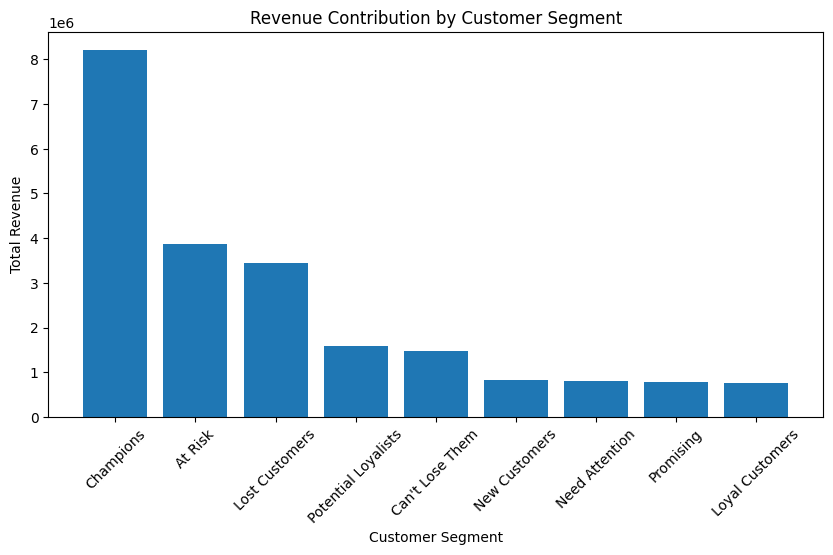

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    segment_revenue["Customer_Segment"],
    segment_revenue["Total_Revenue"]
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.show()

### Observation

The revenue contribution analysis demonstrates that customer value is distributed unevenly across the nine customer segments.

The **Champions** segment generates the highest revenue, contributing **37.73%** of total revenue despite representing only **25.68%** of customers. This confirms that Champions are the most valuable customer group and should remain the primary focus of customer retention and loyalty initiatives.

The **At Risk** segment contributes **17.81%** of total revenue, making it the second most valuable customer group. Although these customers have historically generated substantial revenue, their declining engagement highlights an important opportunity for targeted retention and win-back campaigns.

While **Lost Customers** represent the largest customer segment (**26.11%**), they contribute only **15.85%** of total revenue. This suggests that many inactive customers have relatively low spending behaviour, indicating that reactivation strategies should be carefully prioritised based on potential customer value.

Overall, the analysis demonstrates that a relatively small number of highly engaged customers contribute a disproportionately large share of total revenue, reinforcing the importance of customer segmentation for supporting data-driven marketing and customer relationship management (CRM) strategies.

## Executive Customer Segment Profile

The final stage of the RFM analysis summarises the key characteristics of each customer segment into a single executive overview.

This profile combines customer size, revenue contribution and average purchasing behaviour, providing a comprehensive comparison of the identified customer segments. By integrating these key performance indicators, decision-makers can quickly understand the relative importance of each segment and identify opportunities for customer retention, growth and targeted marketing strategies.

The executive customer segment profile serves as the primary summary of the RFM analysis and provides the foundation for subsequent business recommendations and customer relationship management (CRM) initiatives.

In [ ]:
executive_summary = (
    rfm.groupby("Customer_Segment")
       .agg(
           Customers=("Customer_Segment", "size"),
           Average_Recency=("Recency", "mean"),
           Average_Frequency=("Frequency", "mean"),
           Average_Monetary=("Monetary", "mean"),
           Total_Revenue=("Monetary", "sum")
       )
       .round({
           "Average_Recency": 2,
           "Average_Frequency": 2,
           "Average_Monetary": 2,
           "Total_Revenue": 2
       })
)

# Percentage of customers
executive_summary["Customer_Percentage"] = (
    executive_summary["Customers"]
    / executive_summary["Customers"].sum()
    * 100
).round(2)

# Percentage of revenue
executive_summary["Revenue_Percentage"] = (
    executive_summary["Total_Revenue"]
    / executive_summary["Total_Revenue"].sum()
    * 100
).round(2)

# Arrange columns
executive_summary = executive_summary[
    [
        "Customers",
        "Customer_Percentage",
        "Total_Revenue",
        "Revenue_Percentage",
        "Average_Recency",
        "Average_Frequency",
        "Average_Monetary"
    ]
]

# Sort by revenue contribution
executive_summary = executive_summary.sort_values(
    "Total_Revenue",
    ascending=False
)

executive_summary

,Customers,Customer_Percentage,Total_Revenue,Revenue_Percentage,Average_Recency,Average_Frequency,Average_Monetary
Customer_Segment,,,,,,,
Champions,897,25.68,8203173.55,37.73,20.12,7.93,9145.12
At Risk,494,14.14,3872114.14,17.81,69.47,7.22,7838.29
Lost Customers,912,26.11,3446555.13,15.85,128.19,3.40,3779.12
Potential Loyalists,292,8.36,1589623.98,7.31,20.84,5.00,5443.92
Can't Lose Them,179,5.12,1477984.93,6.80,124.45,6.97,8256.90
New Customers,207,5.93,816776.82,3.76,10.17,3.47,3945.78
Need Attention,153,4.38,809642.80,3.72,65.12,5.00,5291.78
Promising,210,6.01,776160.78,3.57,31.74,3.32,3696.00
Loyal Customers,149,4.27,747463.16,3.44,20.16,6.42,5016.53


**Loyal Customers generating less revenue than Potential Loyalists is unusual.**

### Observation

The Executive Customer Segment Profile provides a comprehensive overview of customer distribution, purchasing behaviour and revenue contribution across the nine customer segments identified through the RFM analysis.

The **Champions** segment represents **25.68%** of customers yet contributes **37.73%** of total revenue, confirming that this group contains the business's highest-value customers. Their low average recency (20.12 days), high purchasing frequency (7.93 transactions) and highest average spending (AUD 9,145.12) indicate strong customer engagement and reinforce the importance of retention and loyalty initiatives.

The **At Risk** segment contributes the second largest share of total revenue (**17.81%**) despite representing only **14.14%** of customers. Although these customers have historically purchased frequently and generated substantial revenue, their higher average recency (69.47 days) suggests declining engagement, making them a priority for targeted retention and win-back campaigns.

While **Lost Customers** account for the largest proportion of the customer base (**26.11%**), they contribute only **15.85%** of total revenue and exhibit relatively low purchasing frequency and spending behaviour. This suggests that customer reactivation strategies should be selectively targeted rather than applied uniformly across all inactive customers.

Overall, the Executive Customer Segment Profile demonstrates that customer value is unevenly distributed across the customer base. A relatively small proportion of highly engaged customers contributes a disproportionately large share of total revenue, highlighting the value of RFM segmentation in supporting evidence-based customer relationship management (CRM), marketing and retention strategies.

In [ ]:
transactions.head()

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date
0,1293,67,1931,2017-01-01,1,Approved,Norco Bicycles,Road,medium,medium,544.05,376.84,2005-10-22
1,3525,50,3490,2017-01-01,1,Approved,Giant Bicycles,Standard,medium,medium,642.70,211.37,2002-03-22
2,12544,36,3062,2017-01-01,0,Approved,Solex,Standard,low,medium,945.04,507.58,1995-12-19
3,12485,85,2805,2017-01-01,1,Approved,WeareA2B,Standard,medium,medium,1228.07,400.91,2000-05-22
4,3518,58,523,2017-01-01,1,Approved,OHM Cycles,Standard,medium,medium,912.52,141.40,2015-05-21


In [ ]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Code,Total_RFM_Score,Customer_Segment
customer_id,,,,,,,,,
1,8,11,9084.45,4,4,4,444,12,Champions
2,129,3,4149.07,1,1,2,112,4,Lost Customers
3,103,8,9888.23,1,4,4,144,9,Can't Lose Them
4,196,2,1047.72,1,1,1,111,3,Lost Customers
5,17,6,5903.20,4,3,2,432,9,Loyal Customers


In [ ]:
# Convert customer_id from the index to a normal column
rfm_merge = rfm.reset_index()

# Merge RFM into the transactions table
transactions_dashboard = transactions.merge(
    rfm_merge,
    on="customer_id",
    how="left",
    validate="many_to_one"
)

In [ ]:
transactions_dashboard.head()

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Code,Total_RFM_Score,Customer_Segment
0,1293,67,1931,2017-01-01,1,Approved,Norco Bicycles,Road,medium,medium,544.05,376.84,2005-10-22,24.0,3.0,2218.50,3.0,1.0,1.0,311,5.0,Promising
1,3525,50,3490,2017-01-01,1,Approved,Giant Bicycles,Standard,medium,medium,642.70,211.37,2002-03-22,167.0,5.0,4739.70,1.0,2.0,2.0,122,5.0,Lost Customers
2,12544,36,3062,2017-01-01,0,Approved,Solex,Standard,low,medium,945.04,507.58,1995-12-19,47.0,6.0,6083.87,2.0,3.0,3.0,233,8.0,At Risk
3,12485,85,2805,2017-01-01,1,Approved,WeareA2B,Standard,medium,medium,1228.07,400.91,2000-05-22,4.0,5.0,5915.90,4.0,2.0,2.0,422,8.0,Potential Loyalists
4,3518,58,523,2017-01-01,1,Approved,OHM Cycles,Standard,medium,medium,912.52,141.40,2015-05-21,19.0,6.0,6485.21,3.0,3.0,3.0,333,9.0,Champions


In [ ]:
transactions_dashboard.shape

(19803, 22)

In [ ]:
transactions_dashboard.columns

Index(['transaction_id', 'product_id', 'customer_id', 'transaction_date',
       'online_order', 'order_status', 'brand', 'product_line',
       'product_class', 'product_size', 'list_price', 'standard_cost',
       'product_first_sold_date', 'Recency', 'Frequency', 'Monetary',
       'R_Score', 'F_Score', 'M_Score', 'RFM_Code', 'Total_RFM_Score',
       'Customer_Segment'],
      dtype='object')

In [ ]:
transactions_dashboard[['customer_id', 'Recency', 'Frequency', 'Monetary', 'Customer_Segment']].head(10)

,customer_id,Recency,Frequency,Monetary,Customer_Segment
0,1931,24.0,3.0,2218.50,Promising
1,3490,167.0,5.0,4739.70,Lost Customers
2,3062,47.0,6.0,6083.87,At Risk
3,2805,4.0,5.0,5915.90,Potential Loyalists
4,523,19.0,6.0,6485.21,Champions
5,3073,252.0,3.0,3426.95,Lost Customers
6,2298,46.0,5.0,4992.19,Need Attention
7,3470,3.0,8.0,14126.25,Champions
8,2552,36.0,6.0,8603.02,Champions
9,234,12.0,9.0,11070.19,Champions


In [ ]:
transactions_dashboard[['Recency', 'Frequency', 'Monetary', 'Customer_Segment']].isna().sum()

,0
Recency,1
Frequency,1
Monetary,1
Customer_Segment,1


In [ ]:
transactions_dashboard[
    transactions_dashboard['Customer_Segment'].isna()
]

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Code,Total_RFM_Score,Customer_Segment
12196,6799,83,287,2017-08-14,1,Cancelled,Solex,Touring,medium,large,2083.94,675.03,2013-09-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
transactions_dashboard = transactions[
    transactions["order_status"] == "Approved"
].merge(
    rfm.reset_index(),
    on="customer_id",
    how="left",
    validate="many_to_one"
)

In [ ]:
# Keep only approved transactions
transactions_dashboard = transactions[
    transactions["order_status"] == "Approved"
].copy()

In [ ]:
transactions_dashboard.shape

(19625, 13)

In [ ]:
# Keep only approved transactions and merge with RFM
transactions_dashboard = (
    transactions[transactions["order_status"] == "Approved"]
    .merge(
        rfm.reset_index(),
        on="customer_id",
        how="left",
        validate="many_to_one"
    )
)

In [ ]:
transactions_dashboard.shape

(19625, 22)

In [ ]:
transactions_dashboard.to_csv(
    "transactions_dashboard.csv",
    index=False
)

print("Export completed!")

Export completed!
